In [1]:
#adicionando retorno no diretório ao caminho
import sys
sys.path.append('../')

#ignorar warnings 
import warnings
warnings.filterwarnings('ignore')

#informação de diretórios
from src.globals import *
from src.models import *
from src.auxiliar_xhealth import *

2025-02-03 13:53:32.064 | INFO     | src.globals:<module>:7 - PROJ_ROOT path is C:\Users\Natalia\OneDrive\Documentos\PROJETOS\x_health


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
import xgboost as xgb
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
#importando a base do arquivo externo
nome_base = f'{EXTERNAL_DATA_DIR}/dataset_2021-5-26-10-14.csv'
df = pd.read_csv(nome_base, sep = '\t', encoding='utf-8', na_values="missing")
logger.info(f'Base importada com tamanho: {len(df)}')

2025-02-03 13:54:00.888 | INFO     | __main__:<module>:4 - Base importada com tamanho: 117273


In [4]:
#Definir a variavel alvo
var_alvo = 'default'  # Variável alvo

In [5]:
df.columns.values

array(['default_3months', 'ioi_36months', 'ioi_3months',
       'valor_por_vencer', 'valor_vencido', 'valor_quitado',
       'quant_protestos', 'valor_protestos', 'quant_acao_judicial',
       'acao_judicial_valor', 'participacao_falencia_valor',
       'dividas_vencidas_valor', 'dividas_vencidas_qtd',
       'falencia_concordata_qtd', 'tipo_sociedade', 'opcao_tributaria',
       'atividade_principal', 'forma_pagamento', 'valor_total_pedido',
       'month', 'year', 'default'], dtype=object)

In [6]:
df.isna().sum().sort_values(ascending=False)

forma_pagamento                32477
opcao_tributaria               18325
tipo_sociedade                   608
atividade_principal              592
default_3months                    0
ioi_36months                       0
valor_quitado                      0
valor_vencido                      0
valor_por_vencer                   0
ioi_3months                        0
quant_protestos                    0
valor_protestos                    0
quant_acao_judicial                0
acao_judicial_valor                0
falencia_concordata_qtd            0
dividas_vencidas_qtd               0
dividas_vencidas_valor             0
participacao_falencia_valor        0
valor_total_pedido                 0
month                              0
year                               0
default                            0
dtype: int64

In [7]:
## Agrupar as formas de pagamento
variavel_alvo = 'forma_pagamento'
variavel_agrupada = f'{variavel_alvo}_agrup'
df[variavel_agrupada] = agrupar_prazo(df, variavel_alvo)

In [8]:
## Agrupar tipos de sociedade de pagamento
variavel_alvo = 'tipo_sociedade'
variavel_agrupada = f'{variavel_alvo}_agrup'
df[variavel_agrupada] = agrupar_tipo_sociedade(df, variavel_alvo)

In [9]:
df_tratado = tratar_categoricas(df)


### Information Value (IV)  >= 0.02) ###
                       Variavel        IV
0              opcao_tributaria  0.191230
1                         month  0.143443
2                 valor_vencido  0.098016
3                   ioi_3months  0.095854
4           atividade_principal  0.076543
5               forma_pagamento  0.070292
6                  ioi_36months  0.069786
7            valor_total_pedido  0.063829
8         forma_pagamento_agrup  0.050392
9                tipo_sociedade  0.034104
10                valor_quitado  0.033826
11                         year  0.029051
12             valor_por_vencer  0.009664
13      falencia_concordata_qtd  0.001220
14              default_3months  0.000000
15              quant_protestos  0.000000
16         dividas_vencidas_qtd  0.000000
17       dividas_vencidas_valor  0.000000
18  participacao_falencia_valor  0.000000
19          quant_acao_judicial  0.000000
20              valor_protestos  0.000000
21          acao_judicial_valor  0

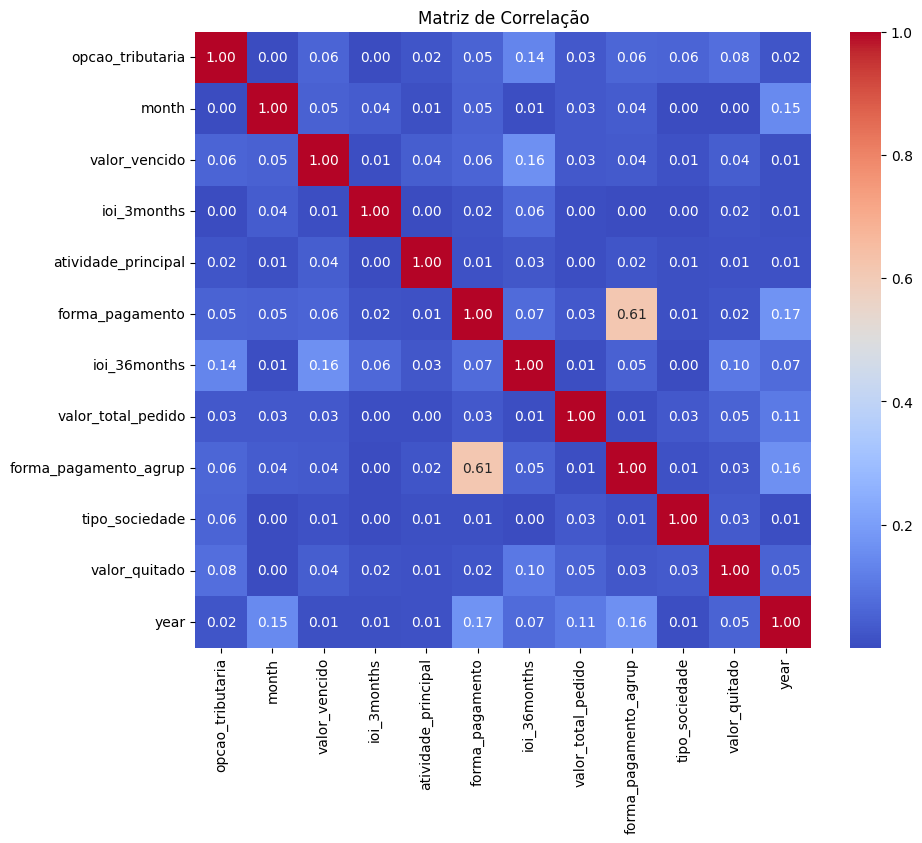


### Mutual Information (MI) ###
                 Variavel        MI
0        opcao_tributaria  0.026862
9          tipo_sociedade  0.015352
8   forma_pagamento_agrup  0.012519
1                   month  0.011907
5         forma_pagamento  0.011300
3             ioi_3months  0.010579
6            ioi_36months  0.007619
11                   year  0.007559
4     atividade_principal  0.007252
2           valor_vencido  0.006880
7      valor_total_pedido  0.005559
10          valor_quitado  0.004526


In [10]:
df_selecao = selecionar_variaveis(df_tratado, target='default')

In [11]:
df_selecao.columns.values

array(['opcao_tributaria', 'tipo_sociedade', 'forma_pagamento_agrup',
       'month', 'forma_pagamento', 'ioi_3months', 'ioi_36months', 'year',
       'atividade_principal', 'valor_vencido', 'default'], dtype=object)

In [30]:
df_tratado.columns.values

array(['default_3months', 'ioi_36months', 'ioi_3months',
       'valor_por_vencer', 'valor_vencido', 'valor_quitado',
       'quant_protestos', 'valor_protestos', 'quant_acao_judicial',
       'acao_judicial_valor', 'participacao_falencia_valor',
       'dividas_vencidas_valor', 'dividas_vencidas_qtd',
       'falencia_concordata_qtd', 'tipo_sociedade', 'opcao_tributaria',
       'atividade_principal', 'forma_pagamento', 'valor_total_pedido',
       'month', 'year', 'default', 'forma_pagamento_agrup',
       'tipo_sociedade_agrup'], dtype=object)

In [12]:
## preparar variaveis e separar em teste e treino
X_train, X_test, y_train, y_test = preparar_dados(df_tratado, target='default')

## Feature Importance

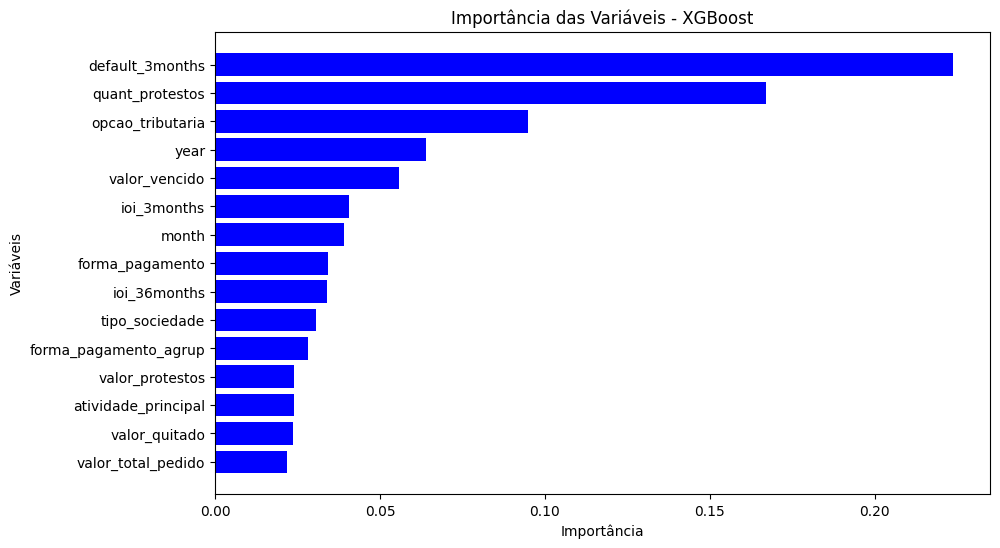

Variáveis Selecionadas: ['default_3months', 'quant_protestos', 'opcao_tributaria', 'year', 'valor_vencido', 'ioi_3months', 'month', 'forma_pagamento', 'ioi_36months', 'tipo_sociedade', 'forma_pagamento_agrup', 'valor_protestos', 'atividade_principal', 'valor_quitado', 'valor_total_pedido']


In [31]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

def selecionar_pelo_xgboost(X_train, y_train, top_n=10):
    """
    Treina um modelo XGBoost e seleciona as principais variáveis com base na importância.

    Parâmetros:
    -----------
    X_train : pd.DataFrame
        Conjunto de treino contendo apenas as variáveis preditoras.
    y_train : pd.Series
        Variável alvo (default = 0 ou 1).
    top_n : int, opcional (default=10)
        Número de variáveis mais importantes a serem selecionadas.

    Retorno:
    --------
    list
        Lista com as variáveis mais importantes.
    """
    
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
    model.fit(X_train, y_train)
    
    # Importância das features
    importance = pd.DataFrame({"Variável": X_train.columns, "Importância": model.feature_importances_})
    importance = importance.sort_values(by="Importância", ascending=False).head(top_n)
    
    # Plot da importância das variáveis
    plt.figure(figsize=(10,6))
    plt.barh(importance["Variável"], importance["Importância"], color="blue")
    plt.xlabel("Importância")
    plt.ylabel("Variáveis")
    plt.title("Importância das Variáveis - XGBoost")
    plt.gca().invert_yaxis()
    plt.show()
    
    return importance["Variável"].tolist()

# Exemplo de uso
top_features = selecionar_pelo_xgboost(X_train, y_train, top_n=15)
print("Variáveis Selecionadas:", top_features)

In [13]:
# Criando os DMatrix para XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [14]:
# Configuração do modelo
params = {
    'objective': 'binary:logistic',  # Classificação binária
    'eval_metric': 'auc',        # Log Loss como métrica de erro
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100
}

### Modelo pre-optuna

In [15]:
# Treinando o modelo
model = xgb.train(params, dtrain, num_boost_round=100)

In [16]:
# Chamando a função de avaliação:
metrica_inicial = avaliar_XGBoost(model, dtrain, y_train, dtest, y_test)
metrica_inicial

,Métrica,Treino,Teste
0,AUC-ROC,0.916665,0.896900
1,Acurácia,0.901085,0.895204
2,Precisão,0.884188,0.851332
3,Recall,0.467767,0.449731
4,F1-score,0.611845,0.588550
5,Log Loss,0.256679,0.273199


In [17]:
# Previsões de probabilidades
y_pred_train_prob = model.predict(dtrain)
y_pred_test_prob = model.predict(dtest)

# Convertendo as probabilidades para classificação binária (0 ou 1)
y_pred_train = (y_pred_train_prob > 0.5).astype(int)
y_pred_test = (y_pred_test_prob > 0.5).astype(int)

# Valores reais (y_true)
y_true_train = y_train.values
y_true_test = y_test.values

Figura salva em: C:\Users\Natalia\OneDrive\Documentos\PROJETOS\x_health\reports\figures/matriz_confusao_XGBoost_inicial.png


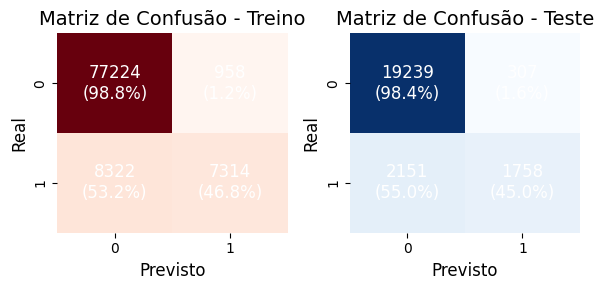

In [18]:
plot_matriz_confusao(y_true_train, y_pred_train, y_true_test, y_pred_test, 
                     size=(6,3), cmap_train="Reds", cmap_test="Blues", 
                     save_path=f'{FIGURES_DIR}/matriz_confusao_XGBoost_inicial.png')

#### Optuna

In [19]:
# desabilita warnings do optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Configurar o nível de log no Optuna
logger.disable("optuna")  # Desativa logs do Optuna no loguru

In [20]:
#metrica da função
metrica = "test-auc-mean"

# Função de otimização do Optuna
def objective(trial):
    
    """
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",  # Avalia a métrica AUC
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "subsample": 0.80,  # Mantendo fixo
        "colsample_bytree": 0.80,  # Mantendo fixo
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0),  # Regularização L2
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0),  # Regularização L1
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "n_jobs": -1  # Habilita paralelização
    }
    
    
    """    
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",  # Avalia a métrica AUC
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "subsample": trial.suggest_float("subsample", 0.79, 0.81),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.79, 0.81),
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0), # Regularização L2
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0), # Regularização L1
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "n_jobs": -1  # Habilita paralelização
    }


    # Executa validação cruzada com 5 folds
    cv_results = xgb.cv(
        params, dtrain, num_boost_round=100,
        nfold=5, stratified=True, early_stopping_rounds=10, seed=42
    )

    # Exibir colunas disponíveis para depuração de metrica
    # print("Colunas disponíveis no cv_results:", cv_results.columns)

    # Capturar a métrica correta
    metric_column = [col for col in cv_results.columns if metrica in col]

    if not metric_column:
        raise ValueError(f"Métrica '{metrica}' não encontrada! Colunas disponíveis: {cv_results.columns}")
    return max(cv_results[metric_column[0]])  # Maximiza AUC

In [21]:
# Executar a otimização com paralelização
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=20, n_jobs=-1)  # Executa múltiplos trials em paralelo

In [22]:
# Melhor conjunto de hiperparâmetros encontrado
best_params = study.best_params
best_value = study.best_value
print("Melhores Hiperparâmetros:", best_params)
print("Melhor Valor:", best_value)

#Melhores Hiperparâmetros: {'max_depth': 9, 'learning_rate': 0.29270414309112364, 'n_estimators': 492, 'subsample': 0.7963351488280979, 'colsample_bytree': 0.8052392449589032, 'lambda': 9.14174843111581, 'alpha': 4.4233718970157465, 'min_child_weight': 4, 'gamma': 0.03469453368455744}
#Melhor Valor: 0.9242312402850119

Melhores Hiperparâmetros: {'max_depth': 6, 'learning_rate': 0.14663204724937728, 'n_estimators': 123, 'subsample': 0.7988254081572157, 'colsample_bytree': 0.8037654250999303, 'lambda': 0.09713626067275127, 'alpha': 0.14168940126851587, 'min_child_weight': 5, 'gamma': 0.48623560407017485}
Melhor Valor: 0.9014117300554177


### Modelo pós-optuna

In [23]:
# Treinar modelo final com melhores hiperparâmetros
xgb_optimized = xgb.train(best_params, dtrain, num_boost_round=100)# Treinar modelo final com melhores hiperparâmetros

In [24]:
# Chamando a função de avaliação:
metrica_final = avaliar_XGBoost(xgb_optimized, dtrain, y_train, dtest, y_test)

In [29]:
metrica_comparada = pd.merge(metrica_inicial, metrica_final, on="Métrica")
metrica_comparada

,Métrica,Treino_x,Teste_x,Treino_y,Teste_y
0,AUC-ROC,0.916665,0.896900,0.913053,0.895709
1,Acurácia,0.901085,0.895204,0.898101,0.891366
2,Precisão,0.884188,0.851332,0.887896,0.850954
3,Recall,0.467767,0.449731,0.444743,0.422103
4,F1-score,0.611845,0.588550,0.592637,0.564295
5,Log Loss,0.256679,0.273199,0.269840,0.292286


Figura salva em: C:\Users\Natalia\OneDrive\Documentos\PROJETOS\x_health\reports\figures/matriz_confusao_XGBoost_final.png


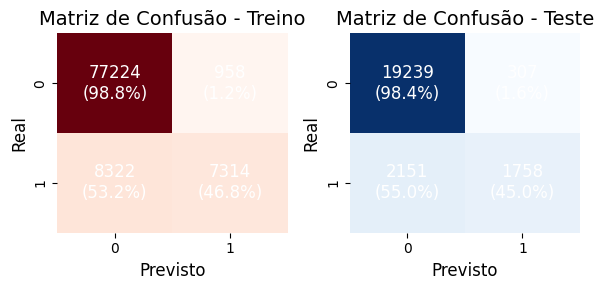

In [28]:
plot_matriz_confusao(y_true_train, y_pred_train, y_true_test, y_pred_test, 
                     size=(6,3), cmap_train="Reds", cmap_test="Blues", 
                     save_path=f'{FIGURES_DIR}/matriz_confusao_XGBoost_final.png')